<a href="https://colab.research.google.com/github/KongathiSandhya/Fish-Image-Classification-by-using-ANN/blob/main/fish_image_classification_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
import tensorflow as tf
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras import datasets

# Load CIFAR-100 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar100.load_data()

# Normalize pixel values
train_images, test_images = train_images / 255.0, test_images / 255.0


169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


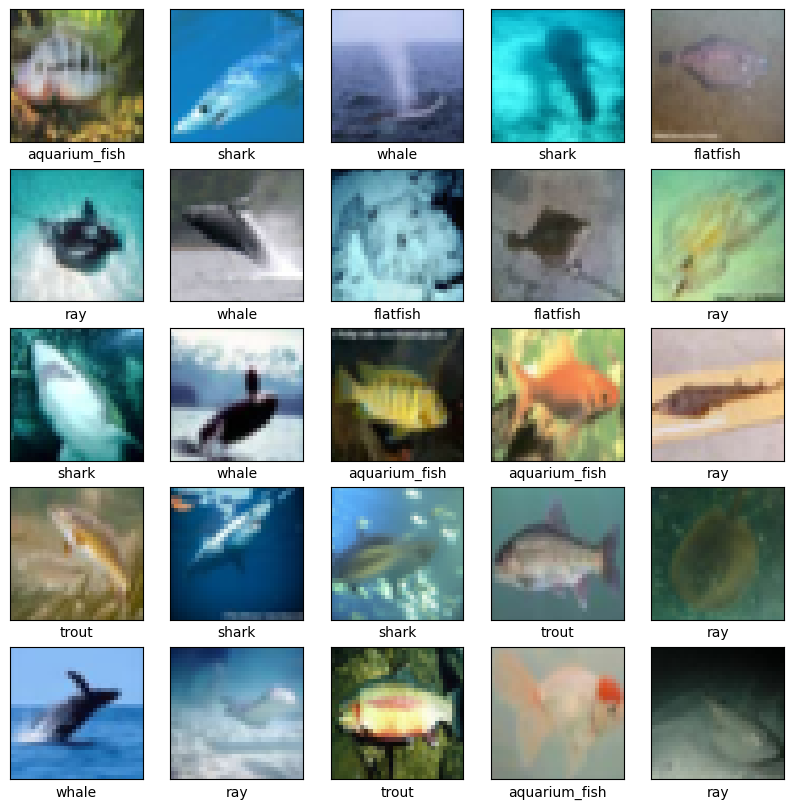

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras import datasets

# CIFAR-100 fine class names (100 categories) - Restored full list
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'computer_keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# Define fish-related classes
fish_classes = ['aquarium_fish', 'flatfish', 'ray', 'shark', 'trout','whale']

# Get indices of fish images
fish_indices = [i for i, label in enumerate(train_labels) if class_names[label[0]] in fish_classes]

# Plot first 25 fish images
plt.figure(figsize=(10,10))
for i in range(25):
    idx = fish_indices[i]
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[idx])
    plt.xlabel(class_names[train_labels[idx][0]])
plt.show()

In [ ]:
ann = tf.keras.models.Sequential()

In [ ]:
ann.add(tf.keras.layers.Conv2D(filters=16,kernel_size=3,activation='relu',
                               input_shape=[32,32,3]))
ann.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann.add(tf.keras.layers.Conv2D(filters=16,kernel_size=3,activation='relu'))
ann.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
ann.add(tf.keras.layers.Flatten())

In [ ]:
ann.add(tf.keras.layers.Dense(units=64,activation='relu'))

In [ ]:
ann.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))

In [ ]:
ann.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,761 (155.32 KB)

 Trainable params: 39,761 (155.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Helper function to create binary labels
def create_binary_labels(labels, class_names, fish_classes):
    binary_labels = []
    for label_idx in labels:
        if class_names[label_idx[0]] in fish_classes:
            binary_labels.append(1) # Fish
        else:
            binary_labels.append(0) # Not fish
    return tf.constant(binary_labels, dtype=tf.int32)

# Create binary labels for training and testing data
train_binary_labels = create_binary_labels(train_labels, class_names, fish_classes)
test_binary_labels = create_binary_labels(test_labels, class_names, fish_classes)

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_binary_labels)).batch(32)
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_binary_labels)).batch(32)


In [ ]:
ann.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

In [ ]:

# Now fit the model
ann.fit(x = train_ds, validation_data = test_ds, epochs = 10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.9395 - loss: 0.2153 - val_accuracy: 0.9414 - val_loss: 0.1897
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9426 - loss: 0.1855 - val_accuracy: 0.9416 - val_loss: 0.1756
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9424 - loss: 0.1753 - val_accuracy: 0.9441 - val_loss: 0.1698
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9454 - loss: 0.1673 - val_accuracy: 0.9440 - val_loss: 0.1660
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9469 - loss: 0.1604 - val_accuracy: 0.9470 - val_loss: 0.1616
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9478 - loss: 0.1539 - val_accuracy: 0.9471 - val_loss: 0.1625
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.9498 - loss: 0.1488 - val_accuracy: 0.9470 - val_loss: 0.1624
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.9516 -

In [ ]:
test_image = tf.keras.utils.load_img('/content/Copilot_20251225_231239.png',
                                     target_size= (64,64))

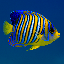

In [ ]:
test_image

In [ ]:
test_image = tf.keras.utils.load_img('/content/Copilot_20251225_231239.png',
                                     target_size= (32,32))

In [ ]:
test_image = tf.keras.utils.img_to_array(test_image)

In [ ]:
import numpy as np
test_image = np.expand_dims(test_image,axis=0)
test_image

array([[[[  0.,  50., 112.],
         [  0.,  50., 111.],
         [  0.,  48., 112.],
         ...,
         [  0.,  43., 115.],
         [  0.,  44., 114.],
         [  0.,  42., 113.]],

        [[  0.,  50., 111.],
         [  0.,  51., 111.],
         [  0.,  50., 113.],
         ...,
         [  0.,  46., 114.],
         [  0.,  44., 114.],
         [  0.,  42., 114.]],

        [[  0.,  50., 112.],
         [  0.,  50., 113.],
         [  0.,  50., 112.],
         ...,
         [  0.,  45., 113.],
         [  0.,  44., 114.],
         [  0.,  42., 113.]],

        ...,

        [[  1.,  69., 113.],
         [  0.,  67., 113.],
         [  0.,  68., 113.],
         ...,
         [  0.,  67., 114.],
         [  0.,  68., 118.],
         [  0.,  70., 117.]],

        [[  0.,  68., 111.],
         [  0.,  69., 114.],
         [  0.,  69., 112.],
         ...,
         [  0.,  71., 116.],
         [  0.,  73., 118.],
         [  0.,  72., 119.]],

        [[  0.,  70., 114.],
       

In [ ]:
result = ann.predict(test_image)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


array([[1.]], dtype=float32)

In [ ]:
if result[0][0] == 1:
  prediction = 'Fish'
else:
  prediction = 'sea animal'

print(prediction)

Fish
